In [17]:
import numpy as np
import scipy.linalg

from scipy import io, integrate, linalg, signal
from scipy.sparse.linalg import cg, eigs
from numpy.random import default_rng

In [18]:
a = np.arange(1, 190, dtype=float).reshape(21, 9)

print("a =")
print(a)

print("\nshape =", a.shape)

a =
[[  1.   2.   3.   4.   5.   6.   7.   8.   9.]
 [ 10.  11.  12.  13.  14.  15.  16.  17.  18.]
 [ 19.  20.  21.  22.  23.  24.  25.  26.  27.]
 [ 28.  29.  30.  31.  32.  33.  34.  35.  36.]
 [ 37.  38.  39.  40.  41.  42.  43.  44.  45.]
 [ 46.  47.  48.  49.  50.  51.  52.  53.  54.]
 [ 55.  56.  57.  58.  59.  60.  61.  62.  63.]
 [ 64.  65.  66.  67.  68.  69.  70.  71.  72.]
 [ 73.  74.  75.  76.  77.  78.  79.  80.  81.]
 [ 82.  83.  84.  85.  86.  87.  88.  89.  90.]
 [ 91.  92.  93.  94.  95.  96.  97.  98.  99.]
 [100. 101. 102. 103. 104. 105. 106. 107. 108.]
 [109. 110. 111. 112. 113. 114. 115. 116. 117.]
 [118. 119. 120. 121. 122. 123. 124. 125. 126.]
 [127. 128. 129. 130. 131. 132. 133. 134. 135.]
 [136. 137. 138. 139. 140. 141. 142. 143. 144.]
 [145. 146. 147. 148. 149. 150. 151. 152. 153.]
 [154. 155. 156. 157. 158. 159. 160. 161. 162.]
 [163. 164. 165. 166. 167. 168. 169. 170. 171.]
 [172. 173. 174. 175. 176. 177. 178. 179. 180.]
 [181. 182. 183. 184. 185. 186. 187.

In [19]:
print("np.ndim(a)")
print(np.ndim(a))

print("\na.ndim")
print(a.ndim)

print("\nnp.size(a)")
print(np.size(a))

print("\na.size")
print(a.size)

print("\nnp.shape(a)")
print(np.shape(a))

print("\na.shape")
print(a.shape)

print("\na.shape[0]")
print(a.shape[0])

print("\na.shape[1]")
print(a.shape[1])


print("\nnp.array([[1., 2., 3.], [4., 5., 6.]])")
print(np.array([[1., 2., 3.], [4., 5., 6.]]))


# Variables specifically for np.block
block_a = np.array([[1., 2.]])
block_b = np.array([[3., 4.]])
block_c = np.array([[5., 6.]])
block_d = np.array([[7., 8.]])

print("\nnp.block([[block_a, block_b], [block_c, block_d]])")
print(np.block([[block_a, block_b], [block_c, block_d]]))


# a[-1] in the tutorial is for a 1D vector
vec = np.array([1., 2., 3., 4., 5.])

print("\nvec[-1]")
print(vec[-1])


print("\na[1, 4]")
print(a[1, 4])

print("\na[1]")
print(a[1])

print("\na[1, :]")
print(a[1, :])

print("\na[0:5]")
print(a[0:5])

print("\na[:5]")
print(a[:5])

print("\na[0:5, :]")
print(a[0:5, :])

print("\na[-5:]")
print(a[-5:])

print("\na[0:3, 4:9]")
print(a[0:3, 4:9])

print("\na[np.ix_([1, 3, 4], [0, 2])]")
print(a[np.ix_([1, 3, 4], [0, 2])])

print("\na[2:21:2, :]")
print(a[2:21:2, :])

print("\na[::2, :]")
print(a[::2, :])

print("\na[::-1, :]")
print(a[::-1, :])

print("\na[np.r_[:len(a), 0]]")
print(a[np.r_[:len(a), 0]])

np.ndim(a)
2

a.ndim
2

np.size(a)
189

a.size
189

np.shape(a)
(21, 9)

a.shape
(21, 9)

a.shape[0]
21

a.shape[1]
9

np.array([[1., 2., 3.], [4., 5., 6.]])
[[1. 2. 3.]
 [4. 5. 6.]]

np.block([[block_a, block_b], [block_c, block_d]])
[[1. 2. 3. 4.]
 [5. 6. 7. 8.]]

vec[-1]
5.0

a[1, 4]
14.0

a[1]
[10. 11. 12. 13. 14. 15. 16. 17. 18.]

a[1, :]
[10. 11. 12. 13. 14. 15. 16. 17. 18.]

a[0:5]
[[ 1.  2.  3.  4.  5.  6.  7.  8.  9.]
 [10. 11. 12. 13. 14. 15. 16. 17. 18.]
 [19. 20. 21. 22. 23. 24. 25. 26. 27.]
 [28. 29. 30. 31. 32. 33. 34. 35. 36.]
 [37. 38. 39. 40. 41. 42. 43. 44. 45.]]

a[:5]
[[ 1.  2.  3.  4.  5.  6.  7.  8.  9.]
 [10. 11. 12. 13. 14. 15. 16. 17. 18.]
 [19. 20. 21. 22. 23. 24. 25. 26. 27.]
 [28. 29. 30. 31. 32. 33. 34. 35. 36.]
 [37. 38. 39. 40. 41. 42. 43. 44. 45.]]

a[0:5, :]
[[ 1.  2.  3.  4.  5.  6.  7.  8.  9.]
 [10. 11. 12. 13. 14. 15. 16. 17. 18.]
 [19. 20. 21. 22. 23. 24. 25. 26. 27.]
 [28. 29. 30. 31. 32. 33. 34. 35. 36.]
 [37. 38. 39. 40. 41. 42. 43. 44. 45.]]

a

In [20]:
# Use small matrices for the following operations
a = np.array([
    [1., 2., 3.],
    [4., 5., 6.],
    [7., 8., 9.]
])

b = np.array([
    [2., 2., 2.],
    [2., 2., 2.],
    [2., 2., 2.]
])

v = np.array([0.2, 0.8, 0.4])

print("a =")
print(a)

print("\nb =")
print(b)


# Transpose
print("\na.transpose()")
print(a.transpose())

print("\na.T")
print(a.T)

print("\na.conj().transpose()")
print(a.conj().transpose())

print("\na.conj().T")
print(a.conj().T)


# Matrix and element-wise operations
print("\na @ b")
print(a @ b)

print("\na * b")
print(a * b)

print("\na / b")
print(a / b)

print("\na ** 3")
print(a ** 3)


# Comparisons
print("\na > 0.5")
print(a > 0.5)

print("\nnp.nonzero(a > 0.5)")
print(np.nonzero(a > 0.5))

print("\na[:, np.nonzero(v > 0.5)[0]]")
print(a[:, np.nonzero(v > 0.5)[0]])

print("\na[:, v.T > 0.5]")
print(a[:, v.T > 0.5])


# Set values based on condition
a_temp = np.array([
    [0.2, 0.7, 0.4],
    [0.8, 0.1, 0.9],
    [0.3, 0.6, 0.5]
])

print("\na_temp before a_temp[a_temp < 0.5] = 0")
print(a_temp)

a_temp[a_temp < 0.5] = 0

print("\na_temp after a_temp[a_temp < 0.5] = 0")
print(a_temp)


a_temp = np.array([
    [0.2, 0.7, 0.4],
    [0.8, 0.1, 0.9],
    [0.3, 0.6, 0.5]
])

print("\na_temp * (a_temp > 0.5)")
print(a_temp * (a_temp > 0.5))


# Set every element to 3
a_temp[:] = 3

print("\na_temp[:] = 3")
print(a_temp)


# Copy
x = np.array([
    [1., 2., 3.],
    [4., 5., 6.],
    [7., 8., 9.]
])

y = x.copy()

print("\ny = x.copy()")
print(y)

y = x[1, :].copy()

print("\ny = x[1, :].copy()")
print(y)


# Flatten
y = x.flatten()

print("\ny = x.flatten()")
print(y)

y = x.flatten('F')

print("\ny = x.flatten('F')")
print(y)

a =
[[1. 2. 3.]
 [4. 5. 6.]
 [7. 8. 9.]]

b =
[[2. 2. 2.]
 [2. 2. 2.]
 [2. 2. 2.]]

a.transpose()
[[1. 4. 7.]
 [2. 5. 8.]
 [3. 6. 9.]]

a.T
[[1. 4. 7.]
 [2. 5. 8.]
 [3. 6. 9.]]

a.conj().transpose()
[[1. 4. 7.]
 [2. 5. 8.]
 [3. 6. 9.]]

a.conj().T
[[1. 4. 7.]
 [2. 5. 8.]
 [3. 6. 9.]]

a @ b
[[12. 12. 12.]
 [30. 30. 30.]
 [48. 48. 48.]]

a * b
[[ 2.  4.  6.]
 [ 8. 10. 12.]
 [14. 16. 18.]]

a / b
[[0.5 1.  1.5]
 [2.  2.5 3. ]
 [3.5 4.  4.5]]

a ** 3
[[  1.   8.  27.]
 [ 64. 125. 216.]
 [343. 512. 729.]]

a > 0.5
[[ True  True  True]
 [ True  True  True]
 [ True  True  True]]

np.nonzero(a > 0.5)
(array([0, 0, 0, 1, 1, 1, 2, 2, 2]), array([0, 1, 2, 0, 1, 2, 0, 1, 2]))

a[:, np.nonzero(v > 0.5)[0]]
[[2.]
 [5.]
 [8.]]

a[:, v.T > 0.5]
[[2.]
 [5.]
 [8.]]

a_temp before a_temp[a_temp < 0.5] = 0
[[0.2 0.7 0.4]
 [0.8 0.1 0.9]
 [0.3 0.6 0.5]]

a_temp after a_temp[a_temp < 0.5] = 0
[[0.  0.7 0. ]
 [0.8 0.  0.9]
 [0.  0.6 0.5]]

a_temp * (a_temp > 0.5)
[[0.  0.7 0. ]
 [0.8 0.  0.9]
 [0.  0.6 0. ]]

In [21]:
print("np.arange(1., 11.)")
print(np.arange(1., 11.))

print("\nnp.r_[1.:11.]")
print(np.r_[1.:11.])

print("\nnp.r_[1:10:10j]")
print(np.r_[1:10:10j])


print("\nnp.arange(10.)")
print(np.arange(10.))

print("\nnp.r_[:10.]")
print(np.r_[:10.])

print("\nnp.r_[:9:10j]")
print(np.r_[:9:10j])


print("\nnp.arange(1., 11.)[:, np.newaxis]")
print(np.arange(1., 11.)[:, np.newaxis])


print("\nnp.zeros((3, 4))")
print(np.zeros((3, 4)))

print("\nnp.zeros((3, 4, 5))")
print(np.zeros((3, 4, 5)))

print("\nnp.ones((3, 4))")
print(np.ones((3, 4)))

print("\nnp.eye(3)")
print(np.eye(3))


a = np.array([
    [1., 2., 3.],
    [4., 5., 6.],
    [7., 8., 9.]
])

print("\nnp.diag(a)")
print(np.diag(a))


v = np.array([1., 2., 3.])

print("\nnp.diag(v, 0)")
print(np.diag(v, 0))

np.arange(1., 11.)
[ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]

np.r_[1.:11.]
[ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]

np.r_[1:10:10j]
[ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]

np.arange(10.)
[0. 1. 2. 3. 4. 5. 6. 7. 8. 9.]

np.r_[:10.]
[0. 1. 2. 3. 4. 5. 6. 7. 8. 9.]

np.r_[:9:10j]
[0. 1. 2. 3. 4. 5. 6. 7. 8. 9.]

np.arange(1., 11.)[:, np.newaxis]
[[ 1.]
 [ 2.]
 [ 3.]
 [ 4.]
 [ 5.]
 [ 6.]
 [ 7.]
 [ 8.]
 [ 9.]
 [10.]]

np.zeros((3, 4))
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]

np.zeros((3, 4, 5))
[[[0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0.]]

 [[0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0.]]

 [[0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0.]]]

np.ones((3, 4))
[[1. 1. 1. 1.]
 [1. 1. 1. 1.]
 [1. 1. 1. 1.]]

np.eye(3)
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

np.diag(a)
[1. 5. 9.]

np.diag(v, 0)
[[1. 0. 0.]
 [0. 2. 0.]
 [0. 0. 3.]]


In [22]:
# Random numbers
rng = default_rng(42)

print("rng.random((3, 4))")
print(rng.random((3, 4)))


# Linspace
print("\nnp.linspace(1, 3, 4)")
print(np.linspace(1, 3, 4))


# Meshgrid using mgrid
print("\nnp.mgrid[0:9., 0:6.]")
print(np.mgrid[0:9., 0:6.])


# Meshgrid
print("\nnp.meshgrid(np.r_[0:9.], np.r_[0:6.])")
print(np.meshgrid(np.r_[0:9.], np.r_[0:6.]))


# Open grid
print("\nnp.ogrid[0:9., 0:6.]")
print(np.ogrid[0:9., 0:6.])


# ix_
print("\nnp.ix_(np.r_[0:9.], np.r_[0:6.])")
print(np.ix_(np.r_[0:9.], np.r_[0:6.]))


# Meshgrid with specific values
print("\nnp.meshgrid([1, 2, 4], [2, 4, 5])")
print(np.meshgrid([1, 2, 4], [2, 4, 5]))


print("\nnp.ix_([1, 2, 4], [2, 4, 5])")
print(np.ix_([1, 2, 4], [2, 4, 5]))


# Tile
a = np.array([
    [1., 2.],
    [3., 4.]
])

m = 2
n = 3

print("\na =")
print(a)

print("\nnp.tile(a, (m, n))")
print(np.tile(a, (m, n)))


# Concatenation
a = np.array([
    [1., 2.],
    [3., 4.]
])

b = np.array([
    [5., 6.],
    [7., 8.]
])

print("\na =")
print(a)

print("\nb =")
print(b)


# Horizontal concatenation
print("\nnp.concatenate((a, b), 1)")
print(np.concatenate((a, b), 1))

print("\nnp.hstack((a, b))")
print(np.hstack((a, b)))

print("\nnp.column_stack((a, b))")
print(np.column_stack((a, b)))

print("\nnp.c_[a, b]")
print(np.c_[a, b])


# Vertical concatenation
print("\nnp.concatenate((a, b))")
print(np.concatenate((a, b)))

print("\nnp.vstack((a, b))")
print(np.vstack((a, b)))

print("\nnp.r_[a, b]")
print(np.r_[a, b])

rng.random((3, 4))
[[0.77395605 0.43887844 0.85859792 0.69736803]
 [0.09417735 0.97562235 0.7611397  0.78606431]
 [0.12811363 0.45038594 0.37079802 0.92676499]]

np.linspace(1, 3, 4)
[1.         1.66666667 2.33333333 3.        ]

np.mgrid[0:9., 0:6.]
[[[0. 0. 0. 0. 0. 0.]
  [1. 1. 1. 1. 1. 1.]
  [2. 2. 2. 2. 2. 2.]
  [3. 3. 3. 3. 3. 3.]
  [4. 4. 4. 4. 4. 4.]
  [5. 5. 5. 5. 5. 5.]
  [6. 6. 6. 6. 6. 6.]
  [7. 7. 7. 7. 7. 7.]
  [8. 8. 8. 8. 8. 8.]]

 [[0. 1. 2. 3. 4. 5.]
  [0. 1. 2. 3. 4. 5.]
  [0. 1. 2. 3. 4. 5.]
  [0. 1. 2. 3. 4. 5.]
  [0. 1. 2. 3. 4. 5.]
  [0. 1. 2. 3. 4. 5.]
  [0. 1. 2. 3. 4. 5.]
  [0. 1. 2. 3. 4. 5.]
  [0. 1. 2. 3. 4. 5.]]]

np.meshgrid(np.r_[0:9.], np.r_[0:6.])
(array([[0., 1., 2., 3., 4., 5., 6., 7., 8.],
       [0., 1., 2., 3., 4., 5., 6., 7., 8.],
       [0., 1., 2., 3., 4., 5., 6., 7., 8.],
       [0., 1., 2., 3., 4., 5., 6., 7., 8.],
       [0., 1., 2., 3., 4., 5., 6., 7., 8.],
       [0., 1., 2., 3., 4., 5., 6., 7., 8.]]), array([[0., 0., 0., 0., 0., 0., 0., 0

In [23]:
# Test matrices
a = np.array([
    [1., 5., 3.],
    [4., 2., 6.],
    [7., 8., 0.]
])

b = np.array([
    [2., 4., 5.],
    [3., 7., 1.],
    [6., 2., 9.]
])

v = np.array([3., 4.])


print("a =")
print(a)

print("\nb =")
print(b)


# Maximum
print("\na.max()")
print(a.max())

print("\nnp.nanmax(a)")
print(np.nanmax(a))

print("\na.max(0)")
print(a.max(0))

print("\na.max(1)")
print(a.max(1))

print("\nnp.maximum(a, b)")
print(np.maximum(a, b))


# Vector norm
print("\nv =")
print(v)

print("\nnp.sqrt(v @ v)")
print(np.sqrt(v @ v))

print("\nnp.linalg.norm(v)")
print(np.linalg.norm(v))


# Logical operations
a_bool = np.array([
    [True, False, True],
    [False, True, False]
])

b_bool = np.array([
    [True, True, False],
    [False, True, True]
])

print("\na_bool =")
print(a_bool)

print("\nb_bool =")
print(b_bool)

print("\nnp.logical_and(a_bool, b_bool)")
print(np.logical_and(a_bool, b_bool))

print("\nnp.logical_or(a_bool, b_bool)")
print(np.logical_or(a_bool, b_bool))

print("\na_bool & b_bool")
print(a_bool & b_bool)

print("\na_bool | b_bool")
print(a_bool | b_bool)

a =
[[1. 5. 3.]
 [4. 2. 6.]
 [7. 8. 0.]]

b =
[[2. 4. 5.]
 [3. 7. 1.]
 [6. 2. 9.]]

a.max()
8.0

np.nanmax(a)
8.0

a.max(0)
[7. 8. 6.]

a.max(1)
[5. 6. 8.]

np.maximum(a, b)
[[2. 5. 5.]
 [4. 7. 6.]
 [7. 8. 9.]]

v =
[3. 4.]

np.sqrt(v @ v)
5.0

np.linalg.norm(v)
5.0

a_bool =
[[ True False  True]
 [False  True False]]

b_bool =
[[ True  True False]
 [False  True  True]]

np.logical_and(a_bool, b_bool)
[[ True False False]
 [False  True False]]

np.logical_or(a_bool, b_bool)
[[ True  True  True]
 [False  True  True]]

a_bool & b_bool
[[ True False False]
 [False  True False]]

a_bool | b_bool
[[ True  True  True]
 [False  True  True]]


In [24]:
# Matrix for inverse, pseudoinverse, rank, solve, SVD, QR, and LU
a = np.array([
    [4., 1., 1.],
    [1., 3., 0.],
    [1., 0., 2.]
])

b = np.array([1., 2., 3.])

print("a =")
print(a)

print("\nb =")
print(b)


# Inverse
print("\nlinalg.inv(a)")
print(linalg.inv(a))


# Pseudoinverse
print("\nlinalg.pinv(a)")
print(linalg.pinv(a))


# Matrix rank
print("\nnp.linalg.matrix_rank(a)")
print(np.linalg.matrix_rank(a))


# Solve ax = b
print("\nlinalg.solve(a, b)")
print(linalg.solve(a, b))


# Least-squares solution
print("\nlinalg.lstsq(a, b)")
print(linalg.lstsq(a, b))


# SVD
U, S, Vh = linalg.svd(a)
V = Vh.T

print("\nU, S, Vh = linalg.svd(a); V = Vh.T")
print("U =")
print(U)
print("S =")
print(S)
print("V =")
print(V)


# Cholesky decomposition
print("\nlinalg.cholesky(a)")
print(linalg.cholesky(a))


# Eigenvalues and eigenvectors
D, V = linalg.eig(a)

print("\nD, V = linalg.eig(a)")
print("D =")
print(D)
print("V =")
print(V)


# Generalized eigenvalue problem
b_matrix = np.array([
    [2., 0., 0.],
    [0., 2., 0.],
    [0., 0., 2.]
])

D, V = linalg.eig(a, b_matrix)

print("\nD, V = linalg.eig(a, b_matrix)")
print("D =")
print(D)
print("V =")
print(V)


# QR decomposition
Q, R = linalg.qr(a)

print("\nQ, R = linalg.qr(a)")
print("Q =")
print(Q)
print("R =")
print(R)


# LU decomposition
P, L, U = linalg.lu(a)

print("\nP, L, U = linalg.lu(a)")
print("P =")
print(P)
print("L =")
print(L)
print("U =")
print(U)

print("\nP @ L @ U")
print(P @ L @ U)

a =
[[4. 1. 1.]
 [1. 3. 0.]
 [1. 0. 2.]]

b =
[1. 2. 3.]

linalg.inv(a)
[[ 0.31578947 -0.10526316 -0.15789474]
 [-0.10526316  0.36842105  0.05263158]
 [-0.15789474  0.05263158  0.57894737]]

linalg.pinv(a)
[[ 0.31578947 -0.10526316 -0.15789474]
 [-0.10526316  0.36842105  0.05263158]
 [-0.15789474  0.05263158  0.57894737]]

np.linalg.matrix_rank(a)
3

linalg.solve(a, b)
[-0.36842105  0.78947368  1.68421053]

linalg.lstsq(a, b)
(array([-0.36842105,  0.78947368,  1.68421053]), array([], dtype=float64), np.int64(3), array([4.87938524, 2.65270364, 1.46791111]))

U, S, Vh = linalg.svd(a); V = Vh.T
U =
[[-0.84402963  0.29312841 -0.44909879]
 [-0.44909879 -0.84402963  0.29312841]
 [-0.29312841  0.44909879  0.84402963]]
S =
[4.87938524 2.65270364 1.46791111]
V =
[[-0.84402963  0.29312841 -0.44909879]
 [-0.44909879 -0.84402963  0.29312841]
 [-0.29312841  0.44909879  0.84402963]]

linalg.cholesky(a)
[[ 2.          0.5         0.5       ]
 [ 0.          1.6583124  -0.15075567]
 [ 0.          0.   

In [25]:
# eigs(a, k=3)
a = np.array([
    [6., 1., 0., 0., 0., 0.],
    [1., 5., 1., 0., 0., 0.],
    [0., 1., 4., 1., 0., 0.],
    [0., 0., 1., 3., 1., 0.],
    [0., 0., 0., 1., 2., 1.],
    [0., 0., 0., 0., 1., 1.]
])

print("a =")
print(a)

D, V = eigs(a, k=3)

print("\nD, V = eigs(a, k=3)")
print("D =")
print(D)
print("V =")
print(V)


# Conjugate Gradient
b = np.array([1., 2., 3., 4., 5., 6.])

print("\nb =")
print(b)

x, info = cg(a, b)

print("\nx, info = cg(a, b)")
print("x =")
print(x)
print("info =")
print(info)


# FFT
a_fft = np.array([1., 2., 3., 4.])

print("\na_fft =")
print(a_fft)

print("\nnp.fft.fft(a_fft)")
fft_result = np.fft.fft(a_fft)
print(fft_result)


# Inverse FFT
print("\nnp.fft.ifft(fft_result)")
print(np.fft.ifft(fft_result))

a =
[[6. 1. 0. 0. 0. 0.]
 [1. 5. 1. 0. 0. 0.]
 [0. 1. 4. 1. 0. 0.]
 [0. 0. 1. 3. 1. 0.]
 [0. 0. 0. 1. 2. 1.]
 [0. 0. 0. 0. 1. 1.]]

D, V = eigs(a, k=3)
D =
[6.74619318+0.j 5.21052759+0.j 4.03509364+0.j]
V =
[[-0.77700441+0.j -0.54099306+0.j -0.29923921+0.j]
 [-0.57979539+0.j  0.4270991 +0.j  0.58797703+0.j]
 [-0.23543035+0.j  0.63090921+0.j -0.26810356+0.j]
 [-0.06674183+0.j  0.3366339 +0.j -0.59738576+0.j]
 [-0.01459742+0.j  0.11322932+0.j -0.35024665+0.j]
 [-0.00254036+0.j  0.02689196+0.j -0.11539896+0.j]]

b =
[1. 2. 3. 4. 5. 6.]

x, info = cg(a, b)
x =
[ 0.10471204  0.37172775  0.03664921  2.48167539 -3.48167539  9.48167539]
info =
0

a_fft =
[1. 2. 3. 4.]

np.fft.fft(a_fft)
[10.+0.j -2.+2.j -2.+0.j -2.-2.j]

np.fft.ifft(fft_result)
[1.+0.j 2.+0.j 3.+0.j 4.+0.j]


In [26]:
# Sorting
a = np.array([
    [3., 1., 2.],
    [6., 4., 5.],
    [9., 7., 8.]
])

print("a =")
print(a)


print("\nnp.sort(a)")
print(np.sort(a))


a_copy = a.copy()
a_copy.sort(axis=0)

print("\na.sort(axis=0)")
print(a_copy)


print("\nnp.sort(a, axis=1)")
print(np.sort(a, axis=1))


a_copy = a.copy()
a_copy.sort(axis=1)

print("\na.sort(axis=1)")
print(a_copy)


# Sort rows based on the first column
a = np.array([
    [3., 30., 300.],
    [1., 10., 100.],
    [2., 20., 200.]
])

print("\na =")
print(a)

I = np.argsort(a[:, 0])
b = a[I, :]

print("\nI = np.argsort(a[:, 0]); b = a[I, :]")
print("I =")
print(I)
print("b =")
print(b)


# Least-squares fitting
Z = np.array([
    [1., 1.],
    [1., 2.],
    [1., 3.],
    [1., 4.]
])

y = np.array([2., 3., 5., 7.])

x = linalg.lstsq(Z, y)

print("\nx = linalg.lstsq(Z, y)")
print(x)


# Resampling
x = np.array([1., 2., 3., 4., 5., 6.])
q = 2

print("\nx =")
print(x)

print("\nsignal.resample(x, int(np.ceil(len(x) / q)))")
print(signal.resample(x, int(np.ceil(len(x) / q))))


# Unique values
a = np.array([1., 2., 2., 3., 3., 3., 4.])

print("\na =")
print(a)

print("\nnp.unique(a)")
print(np.unique(a))


# Squeeze
a = np.array([[[1.], [2.], [3.]]])

print("\na.shape")
print(a.shape)

print("\na.squeeze()")
print(a.squeeze())

print("\na.squeeze().shape")
print(a.squeeze().shape)

a =
[[3. 1. 2.]
 [6. 4. 5.]
 [9. 7. 8.]]

np.sort(a)
[[1. 2. 3.]
 [4. 5. 6.]
 [7. 8. 9.]]

a.sort(axis=0)
[[3. 1. 2.]
 [6. 4. 5.]
 [9. 7. 8.]]

np.sort(a, axis=1)
[[1. 2. 3.]
 [4. 5. 6.]
 [7. 8. 9.]]

a.sort(axis=1)
[[1. 2. 3.]
 [4. 5. 6.]
 [7. 8. 9.]]

a =
[[  3.  30. 300.]
 [  1.  10. 100.]
 [  2.  20. 200.]]

I = np.argsort(a[:, 0]); b = a[I, :]
I =
[1 2 0]
b =
[[  1.  10. 100.]
 [  2.  20. 200.]
 [  3.  30. 300.]]

x = linalg.lstsq(Z, y)
(array([1.23192434e-15, 1.70000000e+00]), array(0.3), np.int64(2), array([5.77937881, 0.77380911]))

x =
[1. 2. 3. 4. 5. 6.]

signal.resample(x, int(np.ceil(len(x) / q)))
[2.5 2.5 5.5]

a =
[1. 2. 2. 3. 3. 3. 4.]

np.unique(a)
[1. 2. 3. 4.]

a.shape
(1, 3, 1)

a.squeeze()
[1. 2. 3.]

a.squeeze().shape
(3,)


In [27]:
# 1. a.shape[n-1]
a = np.arange(1, 190, dtype=float).reshape(21, 9)
n = 1

print("a.shape[n-1]")
print(a.shape[n-1])


# 2. a[-1]
a = np.array([1., 2., 3., 4., 5.])

print("\na[-1]")
print(a[-1])


# 3. np.block([[a, b], [c, d]])
a = np.array([[1., 2.]])
b = np.array([[3., 4.]])
c = np.array([[5., 6.]])
d = np.array([[7., 8.]])

print("\nnp.block([[a, b], [c, d]])")
print(np.block([[a, b], [c, d]]))


# 4. b/a equivalent:
# Solve a.T @ x.T = b.T
a = np.array([
    [4., 1.],
    [1., 3.]
])

b = np.array([
    [1., 2.],
    [3., 4.]
])

x = linalg.solve(a.T, b.T).T

print("\nb/a equivalent: solve a.T @ x.T = b.T")
print(x)

a.shape[n-1]
21

a[-1]
5.0

np.block([[a, b], [c, d]])
[[1. 2. 3. 4.]
 [5. 6. 7. 8.]]

b/a equivalent: solve a.T @ x.T = b.T
[[0.09090909 0.63636364]
 [0.45454545 1.18181818]]


Matplotlib is building the font cache; this may take a moment.


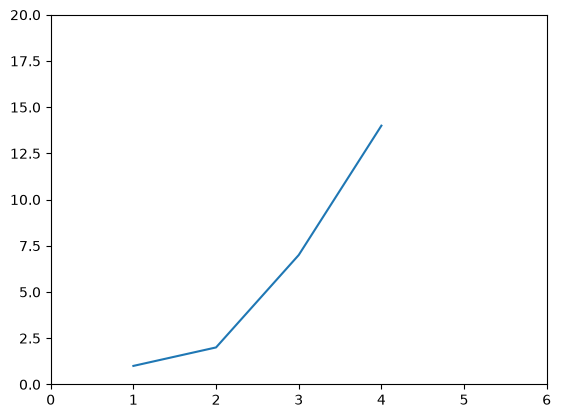

In [28]:
import matplotlib.pyplot as plt

plt.plot([1,2,3,4], [1,2,7,14])
plt.axis([0, 6, 0, 20])
plt.show()

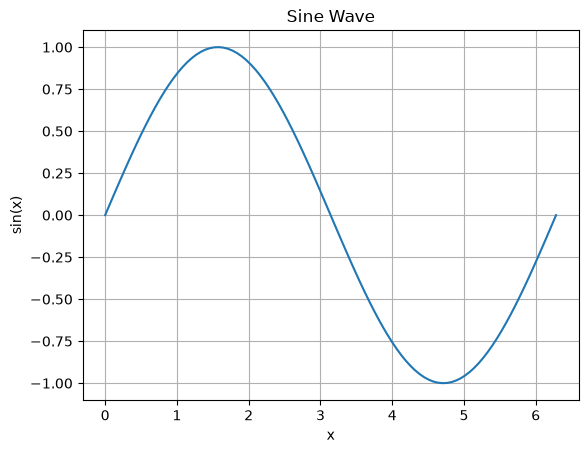

In [29]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0, 2 * np.pi, 100)
y = np.sin(x)

plt.plot(x, y)
plt.title("Sine Wave")
plt.xlabel("x")
plt.ylabel("sin(x)")
plt.grid(True)
plt.show()